# Building Your First Image Classifier with Keras

In Demo 1 we saw a pre-built CNN classify animals. Now it's your turn: load real images, prepare them for a neural network, build a model from scratch, train it, and see what goes right and wrong. We'll use CIFAR-10 — 60,000 tiny color images across 10 classes — and start with the simplest possible architecture: Dense (fully connected) layers.

By the end of this demo you'll be able to:
- Prepare image data for a neural network (normalize, encode, split)
- Build and train a Keras Sequential model
- Read training curves to diagnose overfitting
- Apply regularization techniques (Dropout, L2, Early Stopping)

## Setup

In [1]:
%pip install -q -r requirements.txt

# GPU acceleration (platform-specific)
import platform
if platform.system() == "Darwin" and platform.machine() == "arm64":
    %pip install -q tensorflow-metal

%reset -f

Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

# Constants
REBUILD = False
NUM_CLASSES = 10
EPOCHS = 15
BATCH_SIZE = 128

%mkdir -p models

GPU acceleration: 1 device(s)
  /physical_device:GPU:0


## Load CIFAR-10

CIFAR-10 is bundled with Keras — no external downloads or dataset libraries needed. Each image is 32x32 pixels with 3 color channels (RGB).

In [3]:
(X_train_raw, y_train_raw), (X_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training images: {X_train_raw.shape}")
print(f"Test images:     {X_test.shape}")
print(f"Pixel range:     {X_train_raw.min()} to {X_train_raw.max()}")
print(f"Label shape:     {y_train_raw.shape}")

Training images: (50000, 32, 32, 3)
Test images:     (10000, 32, 32, 3)
Pixel range:     0 to 255
Label shape:     (50000, 1)


## Visualize the Data

Always look at your data before modeling. What do these images actually look like?

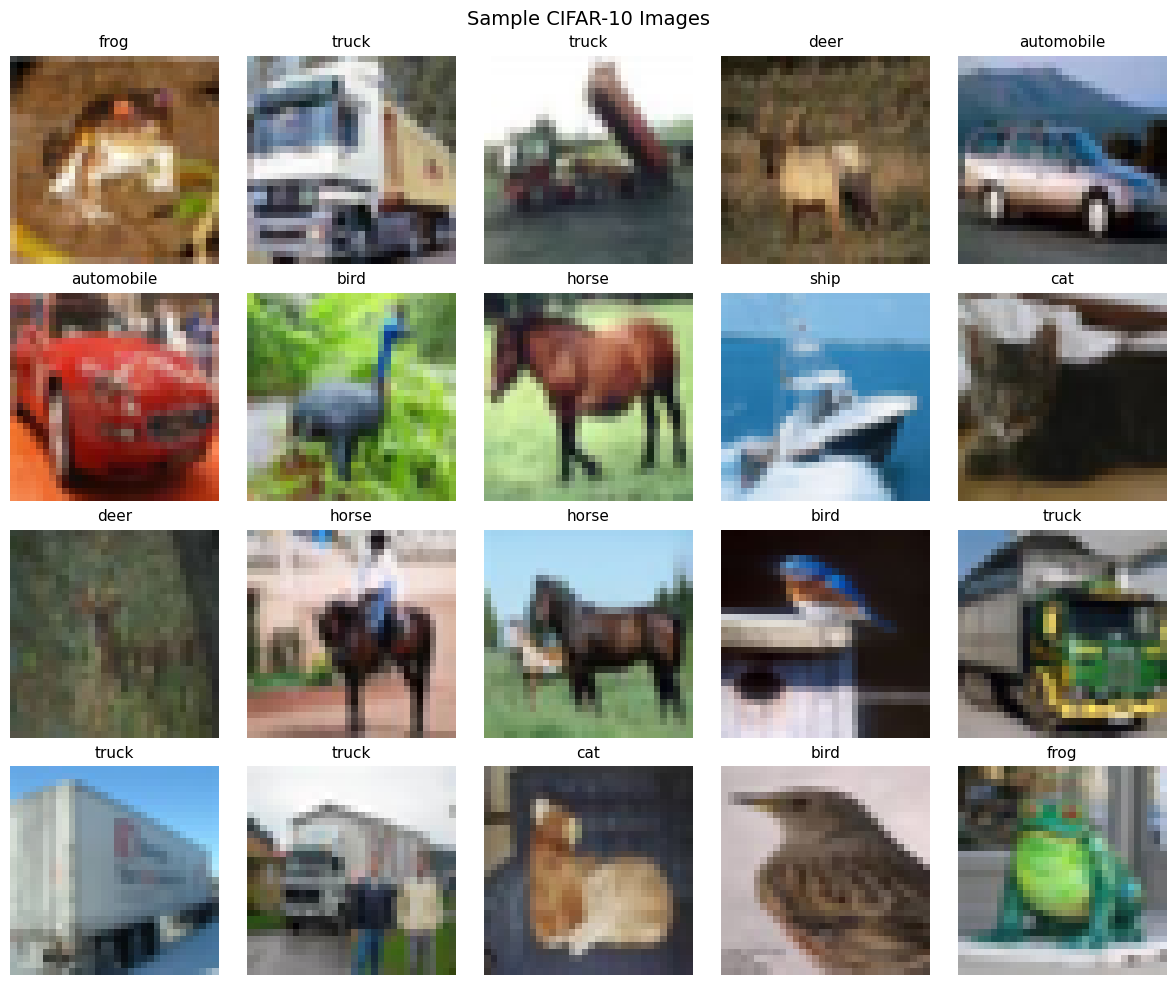

In [4]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i])
    ax.set_title(CLASS_NAMES[y_train_raw[i, 0]], fontsize=11)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

These are small, low-resolution images — sometimes hard even for humans. Let's check the class distribution:

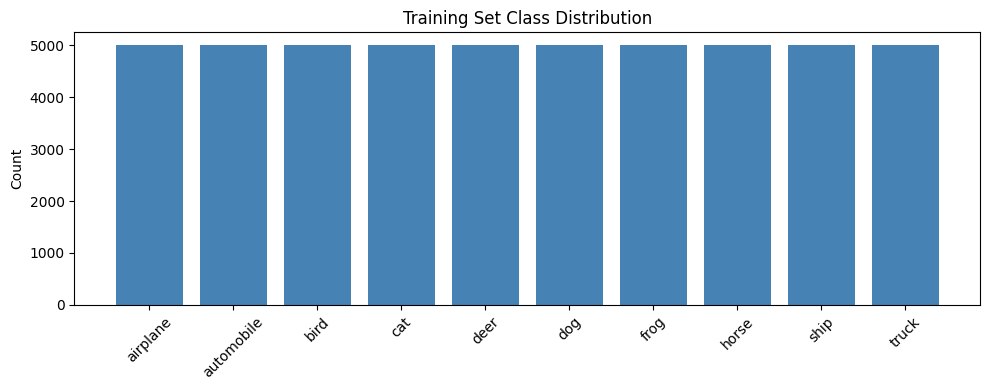

Classes are balanced: 5000 to 5000 images each


In [5]:
unique, counts = np.unique(y_train_raw, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
plt.title('Training Set Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Classes are balanced: {counts.min()} to {counts.max()} images each")

## Prepare Data for Neural Networks

Three essential steps before training:

1. **Normalize** pixel values from [0, 255] to [0, 1] — stabilizes gradient updates
2. **One-hot encode** labels — the output layer produces one probability per class
3. **Split** a validation set from training data — for monitoring overfitting

In [6]:
# Normalize pixel values to [0, 1]
X_train_scaled = X_train_raw.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

# One-hot encode labels: 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_cat = to_categorical(y_train_raw, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

# Hold out 10% of training data for validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_cat, test_size=0.1, random_state=42
)

print(f"Train: {X_train_final.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test_scaled.shape}")

Train: (45000, 32, 32, 3)
Val:   (5000, 32, 32, 3)
Test:  (10000, 32, 32, 3)


## Build a Dense Model

Our first attempt: flatten each 32x32x3 image into a vector of 3,072 numbers, then pass through Dense layers. This is exactly the approach from the lecture — simple, but it throws away all spatial structure.

In [7]:
from keras import Sequential
from keras.layers import Dense, Flatten, Input, BatchNormalization

model_dense = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),                              # 32x32x3 = 3,072 inputs
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(NUM_CLASSES, activation='softmax') # 10 class probabilities
])

model_dense.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,410 (3.14 MB)

 Trainable params: 821,642 (3.13 MB)

 Non-trainable params: 768 (3.00 KB)

## Train the Dense Model

In [8]:
DENSE_PATH = 'models/cifar10_dense.keras'
DENSE_HIST = DENSE_PATH + '.history.pkl'

# Try to download pre-trained model if not rebuilding
if not REBUILD:
    if not os.path.exists(DENSE_PATH):
        !curl -fSL -o {DENSE_PATH} 'https://data.badmath.org/cifar10_dense.keras' 2>/dev/null
    if not os.path.exists(DENSE_HIST):
        !curl -fSL -o {DENSE_HIST} 'https://data.badmath.org/cifar10_dense.keras.history.pkl' 2>/dev/null

# Train from scratch if no model available
if REBUILD or not os.path.exists(DENSE_PATH):
    history_dense = model_dense.fit(
        X_train_final, y_train_final,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val)
    )
    model_dense.save(DENSE_PATH)
    with open(DENSE_HIST, 'wb') as f:
        pickle.dump(history_dense.history, f)
    hist_dense = history_dense.history
else:
    model_dense = keras.models.load_model(DENSE_PATH)
    with open(DENSE_HIST, 'rb') as f:
        hist_dense = pickle.load(f)

print(f"Training complete — {len(hist_dense['loss'])} epochs")

Training complete — 15 epochs


## Training Curves: Diagnosing Overfitting

The gap between training and validation curves tells you whether the model is memorizing (overfitting) or learning general patterns.

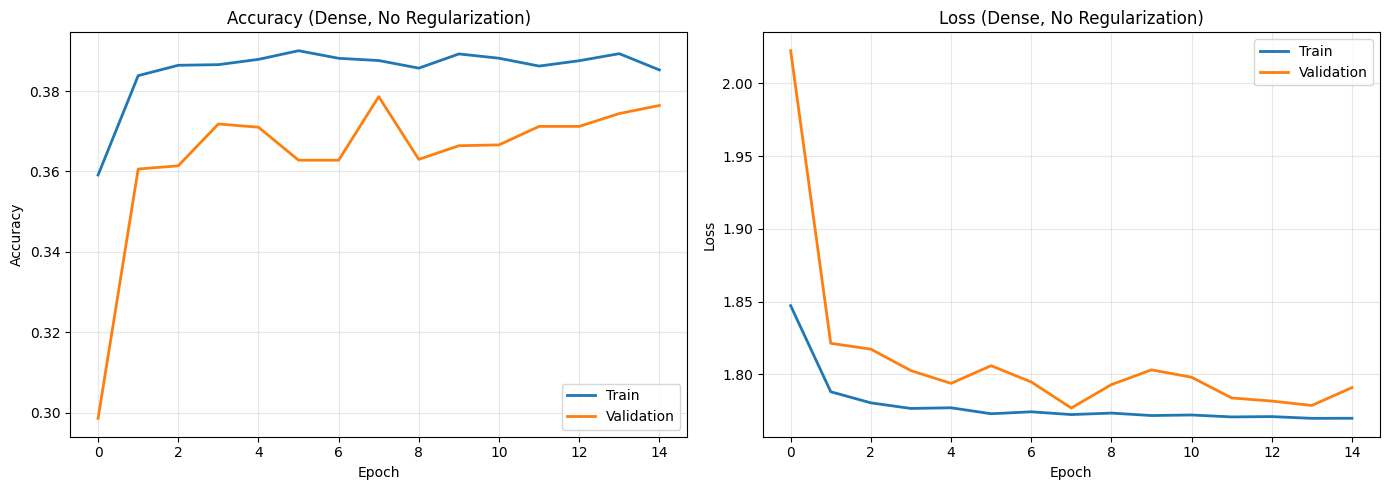

In [9]:
def plot_training_curves(history, title=''):
    """Plot accuracy and loss curves for training and validation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['accuracy'], label='Train', linewidth=2)
    ax1.plot(history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_title(f'Accuracy {title}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['loss'], label='Train', linewidth=2)
    ax2.plot(history['val_loss'], label='Validation', linewidth=2)
    ax2.set_title(f'Loss {title}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(hist_dense, '(Dense, No Regularization)')

Watch for the gap between training and validation curves. When training accuracy is much higher, the model is memorizing training images rather than learning transferable patterns.

## Evaluate on Test Data

In [10]:
test_loss, test_acc = model_dense.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Dense model test accuracy: {test_acc:.2%}")

Dense model test accuracy: 37.70%


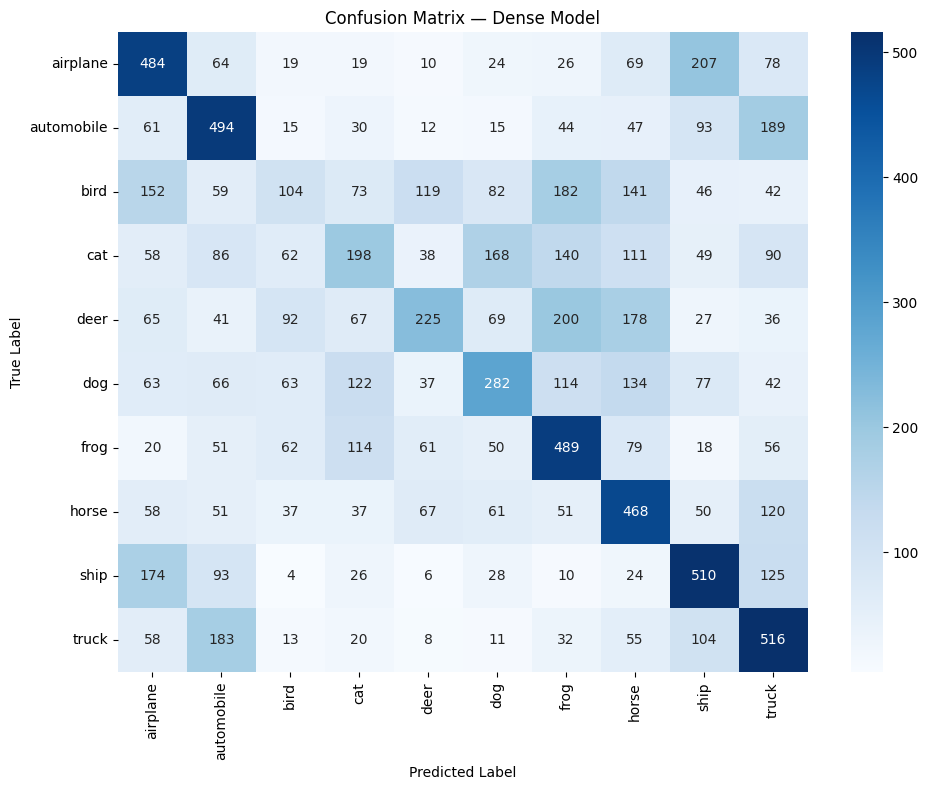

In [11]:
# Confusion matrix — which classes get confused?
y_pred = model_dense.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test.flatten()

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Dense Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

The model struggles with visually similar classes (cat vs. dog, automobile vs. truck). Makes sense: Dense layers see 3,072 independent numbers, not a picture with edges and shapes.

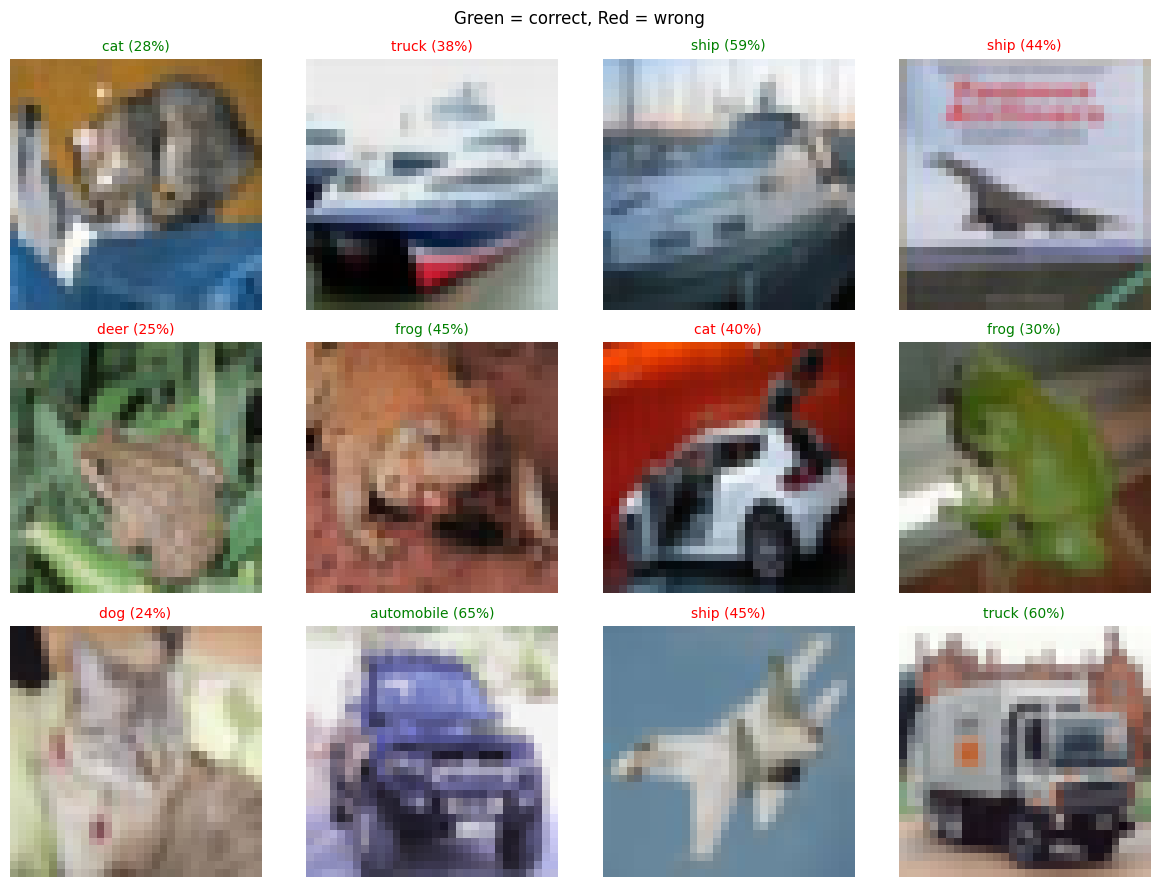

In [12]:
# Show sample predictions
def plot_predictions(model, X, y_true, class_names, n=12, cols=4):
    """Show predictions with green (correct) / red (wrong) labels."""
    preds = model.predict(X[:n], verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = y_true[:n].flatten()

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(X[i])
        correct = pred_classes[i] == true_classes[i]
        color = 'green' if correct else 'red'
        confidence = preds[i][pred_classes[i]]
        ax.set_title(f"{class_names[pred_classes[i]]} ({confidence:.0%})",
                     color=color, fontsize=10)
        ax.axis('off')
    plt.suptitle('Green = correct, Red = wrong', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_predictions(model_dense, X_test_scaled, y_test, CLASS_NAMES)

## Fighting Overfitting: Regularization

The training curves show the model memorizes training data. Let's add regularization:

- **L2 regularization** penalizes large weights, keeping them small
- **Dropout** randomly zeros neurons during training, forcing the network to be redundant
- **Early Stopping** halts training when validation loss stops improving

In [13]:
from keras.layers import Dropout
from keras.callbacks import EarlyStopping
from keras import regularizers

model_reg = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_reg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
REG_PATH = 'models/cifar10_dense_reg.keras'
REG_HIST = REG_PATH + '.history.pkl'

if not REBUILD:
    if not os.path.exists(REG_PATH):
        !curl -fSL -o {REG_PATH} 'https://data.badmath.org/cifar10_dense_reg.keras' 2>/dev/null
    if not os.path.exists(REG_HIST):
        !curl -fSL -o {REG_HIST} 'https://data.badmath.org/cifar10_dense_reg.keras.history.pkl' 2>/dev/null

if REBUILD or not os.path.exists(REG_PATH):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    history_reg = model_reg.fit(
        X_train_final, y_train_final,
        epochs=20,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stop]
    )
    model_reg.save(REG_PATH)
    with open(REG_HIST, 'wb') as f:
        pickle.dump(history_reg.history, f)
    hist_reg = history_reg.history
else:
    model_reg = keras.models.load_model(REG_PATH)
    with open(REG_HIST, 'rb') as f:
        hist_reg = pickle.load(f)

reg_loss, reg_acc = model_reg.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Regularized model test accuracy: {reg_acc:.2%}")

Regularized model test accuracy: 36.07%


## Comparing: With vs. Without Regularization

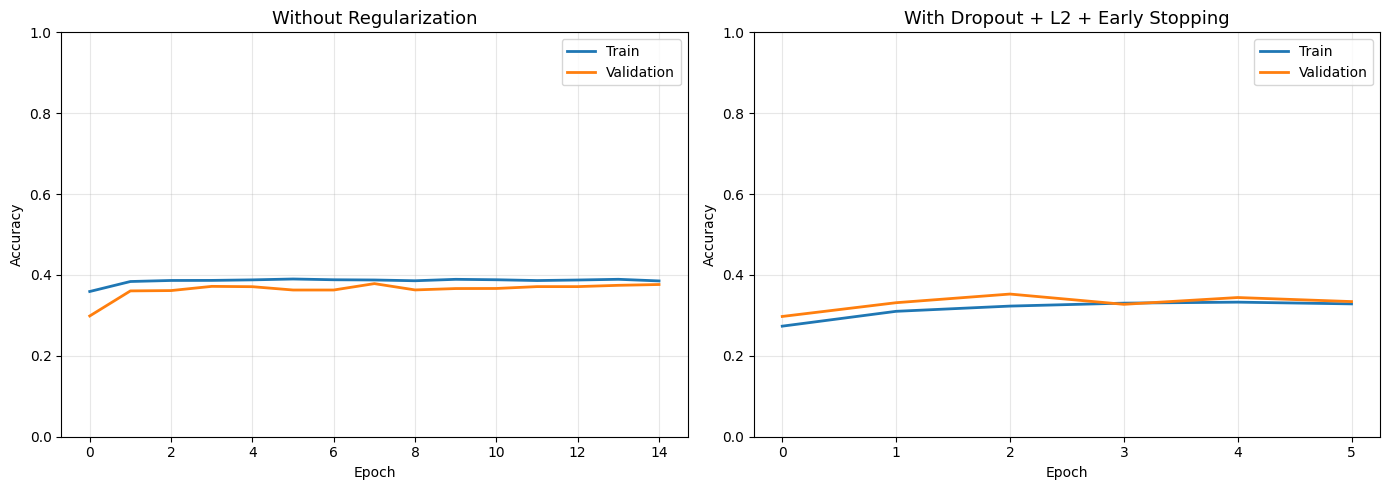


Dense (no reg):   37.70% test accuracy
Dense (with reg): 36.07% test accuracy


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without regularization
axes[0].plot(hist_dense['accuracy'], label='Train', linewidth=2)
axes[0].plot(hist_dense['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Without Regularization', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# With regularization
axes[1].plot(hist_reg['accuracy'], label='Train', linewidth=2)
axes[1].plot(hist_reg['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_title('With Dropout + L2 + Early Stopping', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Match y-axis scales
for ax in axes:
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nDense (no reg):   {test_acc:.2%} test accuracy")
print(f"Dense (with reg): {reg_acc:.2%} test accuracy")

Regularization narrows the gap between training and validation curves — the model overfits less. But the overall accuracy is still modest. Why?

**Dense layers flatten the image into a 1D vector.** The model has no concept of spatial neighbors, edges, or shapes. A pixel in the top-left corner is just as "connected" to the output as the pixel next to it. For images, we need layers that understand spatial structure — that's what CNNs provide in the next demo.